# 03 - UDA-Hub agentic app

This notebook runs the UDA-Hub multi-agent system end to end on real tickets
with the live LLM, and shows the decision trail behind every reply.

**Before running:** execute `01_external_db_setup.ipynb` and `02_core_db_setup.ipynb` (or
`python scripts/setup_databases.py`), and put `OPENAI_API_KEY` (a Vocareum `voc-` key works) in
`.env`. After re-running 01/02, restart this kernel so no old database handle stays open.

| Rubric item | Where below |
|---|---|
| Multi-agent architecture (Supervisor), routing on content + metadata | sections 1-3, every trace (`routed -> ... [rule]`) |
| Knowledge retrieval, confidence, escalation when nothing matches | 3.1, 3.8 |
| Tools over the CultPass DB (MCP), structured responses, error handling | 2, 3.2-3.5 |
| Short-term memory (thread_id), state inspection (messages, tool usage) | 3.2, 4 |
| Long-term memory, returning customers, personalisation | 5 |
| Structured, searchable logs | 6 |
| A/B routing experiment and evaluation | 7 |
| Edge cases (empty message, unknown thread, seeded ticket) | 8 |

Design docs: `agentic/design/ARCHITECTURE.md` and `agentic/design/RAG.md`.

## Setup

In [1]:
from dotenv import load_dotenv
from utils import chat_interface

In [2]:
load_dotenv()

True

In [3]:
# IDEALLY YOUR ONLY IMPORT HERE IS:
# from agentic.workflow import orchestrator

from agentic.workflow import orchestrator

Helpers used below (all thin wrappers around the same graph):
`submit_ticket` opens a ticket like a Zendesk/Intercom connector would, `send_message` runs one
customer turn on the ticket's thread, and `run_scenario` prints the decision trail of each turn.

In [4]:
from IPython.display import Image, display
from agentic.workflow import submit_ticket, send_message, process_ticket, thread_config
from agentic.demo import SCENARIOS, run_scenario
from agentic.logging_utils import search_events, format_event
from agentic.tools.udahub_ops import list_tickets, get_ticket
from agentic.config import get_settings

scenarios = {s.key: s for s in SCENARIOS}
settings = get_settings()
print("chat model:", settings.chat_model, "| embeddings:", settings.embedding_model,
      "| routing strategy:", settings.routing_strategy, "| checkpointer:", settings.checkpointer)

chat model: gpt-4.1-mini | embeddings: text-embedding-3-small | routing strategy: ab | checkpointer: sqlite


## 1. The graph

Supervisor pattern: an intake → classifier → knowledge-retriever pipeline feeds the **supervisor**,
which routes to three tool-using specialists (each reports back to it), a **QA reviewer** that
verifies every answer, or **escalation**. The responder formats and persists the reply and the memory
curator updates long-term memory. Built from scratch with `StateGraph` in `agentic/workflow.py`.

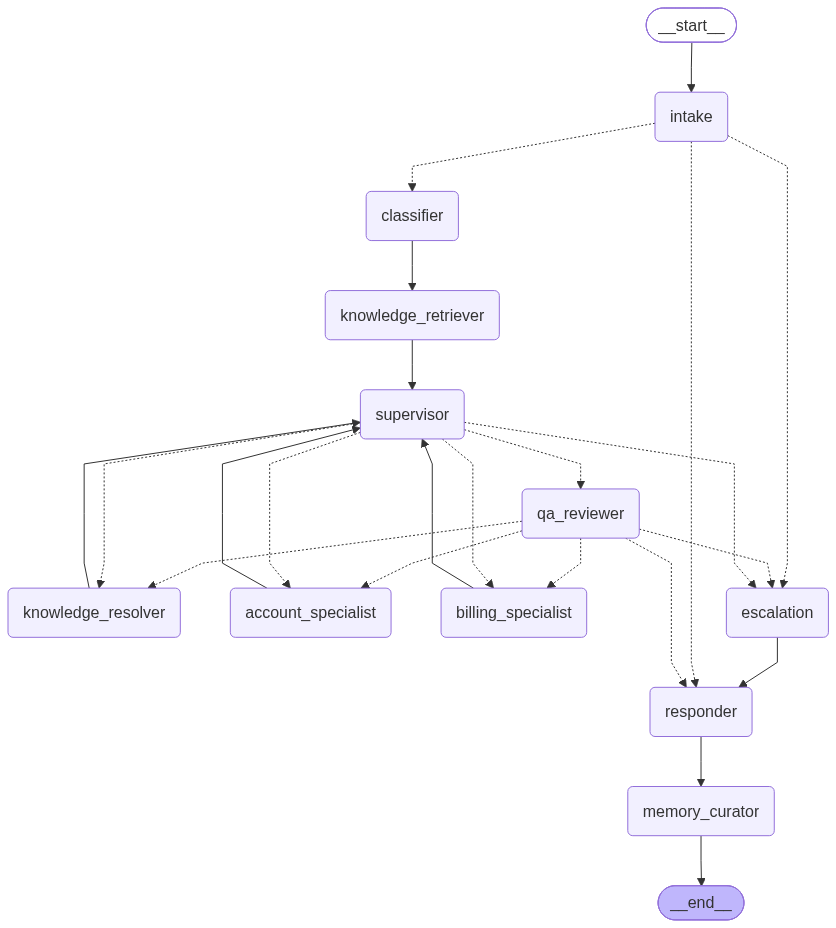

In [5]:
display(Image(filename='agentic/design/workflow_graph.png', width=620))

In [6]:
print(orchestrator.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	intake(intake)
	classifier(classifier)
	knowledge_retriever(knowledge_retriever)
	supervisor(supervisor)
	knowledge_resolver(knowledge_resolver)
	account_specialist(account_specialist)
	billing_specialist(billing_specialist)
	qa_reviewer(qa_reviewer)
	escalation(escalation)
	responder(responder)
	memory_curator(memory_curator)
	__end__([<p>__end__</p>]):::last
	__start__ --> intake;
	account_specialist --> supervisor;
	billing_specialist --> supervisor;
	classifier --> knowledge_retriever;
	escalation --> responder;
	intake -.-> classifier;
	intake -.-> escalation;
	intake -.-> responder;
	knowledge_resolver --> supervisor;
	knowledge_retriever --> supervisor;
	qa_reviewer -.-> account_specialist;
	qa_reviewer -.-> billing_specialist;
	qa_reviewer -.-> escalation;
	qa_reviewer -.-> knowledge_resolver;
	qa_reviewer -.-> responder;
	responder --> memory_curator;
	supervisor -.-> account_speci

## 2. Tools run over MCP

The CultPass support tools are served by a FastMCP server (`agentic/tools/mcp_server.py`) over stdio.
Agents never see `user_id`: the registry injects the ticket owner's id.

In [7]:
registry = orchestrator.services.tools.start()
print("transport:", registry.transport, "| fallback reason:", registry.fallback_reason)
print("tools:", registry.tool_names)
print(registry.call("get_customer_profile", {}, user_id="f556c0"))
print(registry.call("cancel_subscription", {}, user_id="f556c0"))   # validation: needs explicit confirmation

transport: mcp | fallback reason: None
tools: ['get_customer_profile', 'list_reservations', 'search_experiences', 'reserve_experience', 'cancel_reservation', 'pause_subscription', 'resume_subscription', 'cancel_subscription', 'submit_refund_request']


{'ok': True, 'data': {'user_id': 'f556c0', 'full_name': 'Bob Stone', 'email': 'bob.stone@granite.com', 'is_blocked': False, 'member_since': '2026-09-27T02:20', 'subscription': {'subscription_id': 'd64846', 'status': 'active', 'tier': 'basic', 'monthly_quota': 4, 'started_at': '2026-09-15T02:20', 'ended_at': None}, 'quota': {'monthly_quota': 4, 'used_this_cycle': 2, 'remaining': 2, 'cycle_resets_at': '2026-10-15T02:20'}, 'upcoming_reservations': 2}, '_meta': {'transport': 'mcp', 'latency_ms': 825.9}}
{'ok': False, 'error': {'code': 'confirmation_required', 'message': 'ask the customer to confirm the cancellation explicitly, then call again with customer_confirmed=true'}, '_meta': {'transport': 'mcp', 'latency_ms': 7.7}}


## 3. Sample tickets end to end

Each block shows, per turn: the **classification** (with metadata-aware priority), the **retrieval**
confidence and top articles, every **routing decision** with the rule that fired, **tool calls** (and
their transport), the **QA** verdict, and the **outcome** with the knowledge articles the reply is based on.

### 3.1 Knowledge-base resolution
A how-to question: answered only from the retrieved article, then verified by QA.

In [8]:
r_kb_resolution = run_scenario(orchestrator, scenarios['kb_resolution'])

=== Knowledge-base answer  [user f556c0, chat, ticket e7b3260b]
    demonstrates: classification, RAG retrieval, knowledge_resolver, QA, citations, resolved

User: How do I reserve a spot for an event?


  · classified   reservation_booking | urgency=low | sentiment=neutral | priority=P4
  · retrieved    confidence=1.0 | ['How to Reserve a Spot for an Event', 'Event Sold Out and the Waitlist', 'Event Cancelled or Rescheduled by the Partner']
  · routed       -> knowledge_resolver  [A_llm_supervisor] The customer is asking for instructions on how to reserve a spot for an event, which is a how-to question that can be answered by the knowledge_resolver without needing account access.
  · routed       -> qa_reviewer         [S4_review] knowledge_resolver answered; verify before sending
  · QA           passed=True confidence=1.0 
  · outcome      resolved by knowledge_resolver | sources: ['How to Reserve a Spot for an Event']
Assistant: Hi Bob! To reserve a spot for an event, open the CultPass app, browse the experience catalog, and tap 'Reserve' on the event you want. If it's a premium or limited event, check your email for confirmation. Remember to arrive at least 15 minutes early with y

### 3.2 Multi-turn tool use with session memory
Bob has two reservations, so the account specialist asks which one. The second message ('the samba one') only makes sense with the thread's short-term memory; the specialist reuses the exact reservation id from the previous turn's tool result and cancels it over MCP.

In [9]:
r_multi_turn_tools = run_scenario(orchestrator, scenarios['multi_turn_tools'])

=== Two-turn reservation cancellation (session memory + tools)  [user f556c0, chat, ticket 2aab1009]
    demonstrates: account_specialist, MCP tools list/cancel, clarifying question, short-term memory

User: I need to cancel one of my reservations


  · classified   reservation_change | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=0.959 | ['Cancelling a Reservation and the No-Show Policy', 'Event Cancelled or Rescheduled by the Partner', 'Transferring or Sharing a Reservation']
  · routed       -> account_specialist  [A_rules_first] requested action cancel_reservation needs the reservation tools
  · routed       -> qa_reviewer         [S4_review] account_specialist answered; verify before sending
  · tool         account_specialist: list_reservations({'status': 'reserved'}) ok=True via mcp
  · QA           passed=True confidence=0.984 
  · outcome      needs_customer_input by account_specialist | sources: ['Cancelling a Reservation and the No-Show Policy']
Assistant: You have two upcoming reservations: 1) Carnival History Tour in Olinda on 2026-09-28 (cancellation not free, less than 24 hours left), and 2) Samba Night at Lapa on 2026-10-01 (free cancellation, more than 24 hours left). Which one woul

  · classified   reservation_change | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=0.886 | ['Cancelling a Reservation and the No-Show Policy', 'Event Cancelled or Rescheduled by the Partner', 'Transferring or Sharing a Reservation']
  · routed       -> account_specialist  [A_rules_first] requested action cancel_reservation needs the reservation tools
  · routed       -> qa_reviewer         [S4_review] account_specialist answered; verify before sending
  · tool         account_specialist: cancel_reservation({'reservation_id': 'd8b7fa'}) ok=True via mcp
  · QA           passed=True confidence=0.954 
  · outcome      resolved by account_specialist | sources: ['Cancelling a Reservation and the No-Show Policy', 'How the Monthly Experience Quota Works']
Assistant: Your reservation for Samba Night at Lapa has been cancelled successfully. Since you cancelled more than 24 hours before the event, the credit has been returned to your monthly quota. If you need help

### 3.3 Booking an experience
The account specialist searches the catalogue and reserves. `reserve_experience` enforces subscription status, quota and availability.

In [10]:
r_reserve = run_scenario(orchestrator, scenarios['reserve'])

=== Book an experience through tools  [user e6376d, chat, ticket 7a20fffa]
    demonstrates: search_experiences, reserve_experience, quota rules

User: Can you book the Samba Night at Lapa for me?


  · classified   reservation_booking | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=0.436 | ['Transferring or Sharing a Reservation', 'Event Sold Out and the Waitlist', 'How to Reserve a Spot for an Event']
  · routed       -> account_specialist  [A_rules_first] requested action reserve_experience needs the reservation tools
  · routed       -> qa_reviewer         [S4_review] account_specialist answered; verify before sending
  · tool         account_specialist: search_experiences({'query': 'Samba Night at Lapa'}) ok=True via mcp
  · tool         account_specialist: reserve_experience({'experience_id': '60905c'}) ok=True via mcp
  · QA           passed=True confidence=0.9 
  · outcome      resolved by account_specialist | sources: ['How to Reserve a Spot for an Event', 'Premium Experiences and Extra Fees']
Assistant: I've successfully reserved your spot for the Samba Night at Lapa experience in Rio de Janeiro. You still have 4 credits left this month. Re

### 3.4 Tool error handled gracefully
The tool returns `sold_out`; the specialist looks up the waitlist policy and explains it.

In [11]:
r_sold_out = run_scenario(orchestrator, scenarios['sold_out'])

=== Sold-out event: tool error + waitlist policy  [user 88382b, chat, ticket 9f4e50c0]
    demonstrates: tool error handling, follow-up KB search, waitlist article

User: Please book the Ibirapuera Park Bike Ride for me


  · classified   reservation_booking | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=0.381 | ['How to Reserve a Spot for an Event', 'Transferring or Sharing a Reservation', 'Premium Experiences and Extra Fees']
  · routed       -> account_specialist  [A_llm_supervisor] The customer wants to book a specific experience, which requires accessing and modifying their reservation account data.
  · routed       -> qa_reviewer         [S4_review] account_specialist answered; verify before sending
  · tool         account_specialist: search_experiences({'query': 'Ibirapuera Park Bike Ride', 'only_available': True}) ok=True via mcp
  · tool         account_specialist: search_experiences({'query': 'Ibirapuera Park Bike Ride'}) ok=True via mcp
  · QA           passed=True confidence=0.9 
  · outcome      resolved by account_specialist | sources: ['Event Sold Out and the Waitlist']
Assistant: The Ibirapuera Park Bike Ride experience is currently fully booked. You can 

### 3.5 Refund request by email
Quoted history is stripped at intake. The billing specialist submits a refund request (it cannot approve one). By policy that is a hand-off, so the ticket escalates to the billing lead. Email formatting is applied.

In [12]:
r_refund = run_scenario(orchestrator, scenarios['refund'])

=== Refund request (email) -> billing lead  [user 88382b, email, ticket 08bb8337]
    demonstrates: email normalisation, billing_specialist, submit_refund_request, escalation by policy, email formatting

User: Hi, I was charged twice this month for my plan. Please refund the duplicate charge.  Thanks, Cathy  On Mon, CultPass <no-reply@cultpass.com> wrote: > Your recei


  · classified   refund_request | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=1.0 | ['Double Charge or Unrecognized Charge', 'Refund Policy and Refund Requests', 'Event Cancelled or Rescheduled by the Partner']
  · routed       -> billing_specialist  [A_rules_first] refund_request/refund is a billing or subscription operation
  · routed       -> escalation          [S2_specialist] refund awaiting approval
  · tool         billing_specialist: submit_refund_request({'reason': 'Duplicate charge for the same billing period'}) ok=True via mcp
  · escalated    team=billing_lead priority=P3 reason=refund awaiting approval
  · outcome      escalated by escalation | sources: ['Refund Policy and Refund Requests', 'Double Charge or Unrecognized Charge']
Assistant: Hi Cathy, I'm sorry about the confusion with your charges. I've submitted your refund request for the duplicate charge to our billing lead for review. You'll receive an email with the decision within 1 b

### 3.6 Blocked account (guardrail + metadata)
The customer is blocked in CultPass, so guardrail G3 escalates to Trust & Safety before any specialist runs. Urgency flag + sentiment + premium tier raise the priority.

In [13]:
r_blocked = run_scenario(orchestrator, scenarios['blocked'])

=== Blocked account -> Trust & Safety guardrail  [user a4ab87, chat, ticket 735f3876]
    demonstrates: metadata-aware priority, guardrail G3, escalation handoff

User: I can't log in, it says my account is suspended. I have an event tomorrow!


  · classified   login_access | urgency=high | sentiment=negative | priority=P1
  · retrieved    confidence=0.816 | ['How to Handle Login Issues?', "What's Included in a CultPass Subscription", 'Account Blocked or Suspended']
  · routed       -> escalation          [G3_blocked] account is blocked; only Trust & Safety can review it
  · escalated    team=trust_and_safety priority=P1 reason=account is blocked; only Trust & Safety can review it
  · outcome      escalated by escalation | sources: ['When and How Support Escalates to a Human Agent', 'Account Blocked or Suspended']
Assistant: Hi Alice, I understand how frustrating it is not to access your account before your event. Your account is currently restricted, and I've passed your case to our Trust & Safety team. They are the only ones who can review it and will contact you by email within 2 business days.



### 3.7 Safety incident
Guardrail G1 (backed by a keyword backstop in the classifier) escalates immediately with P1.

In [14]:
r_safety = run_scenario(orchestrator, scenarios['safety'])

=== Safety incident (keyword backstop)  [user e6376d, chat, ticket 46c47496]
    demonstrates: guardrail G1, P1 priority, Trust & Safety

User: A staff member at the samba club harassed me last night. I felt unsafe.


  · classified   safety_incident | urgency=high | sentiment=very_negative | priority=P1
  · retrieved    confidence=0.91 | ['Reporting a Problem or Safety Incident at a Venue', 'Suspicious Activity and Account Security', 'Account Blocked or Suspended']
  · routed       -> escalation          [G1_safety] safety incident reported
  · escalated    team=trust_and_safety priority=P1 reason=safety incident reported
  · outcome      escalated by escalation | sources: ['Reporting a Problem or Safety Incident at a Venue']
Assistant: Hi Frank, I'm really sorry to hear about your experience at the samba club. I've escalated your report to our Trust & Safety team as urgent, and they will get back to you within 4 business hours. Meanwhile, if you feel anyone is in immediate danger, please contact local emergency services right away.



### 3.8 Nothing in the knowledge base
Retrieval confidence is below the 0.35 gate, so the system escalates instead of answering from the model's own knowledge.

In [15]:
r_no_article = run_scenario(orchestrator, scenarios['no_article'])

=== Nothing in the knowledge base -> escalation  [user f556c0, chat, ticket 9ea81bae]
    demonstrates: knowledge gate K1, low retrieval confidence, escalation

User: Can you recommend a good pizza recipe?


  · classified   other | urgency=low | sentiment=neutral | priority=P4
  · retrieved    confidence=0.08 | ['Transferring or Sharing a Reservation']
  · routed       -> escalation          [K1_no_article] no relevant knowledge article (retrieval confidence 0.08 < 0.35)
  · escalated    team=tier2_support priority=P4 reason=no relevant knowledge article (retrieval confidence 0.08 < 0.35)
  · outcome      escalated by escalation | sources: ['When and How Support Escalates to a Human Agent']
Assistant: Hi Bob, I understand you're looking for a pizza recipe recommendation. I can only assist with CultPass memberships, reservations, and experiences. If you have any questions related to CultPass, please feel free to ask! Our senior support team will get back to you within 1 business day regarding your inquiry.



### 3.9 Portuguese question on social media
The reply is in the customer's language and formatted for a public channel.

In [16]:
r_portuguese_social = run_scenario(orchestrator, scenarios['portuguese_social'])

=== Portuguese question on social media  [user 88382b, social, ticket 4a5a28ec]
    demonstrates: language detection, social channel formatting

User: Olá! Como faço para reservar uma experiência?


  · classified   reservation_booking | urgency=low | sentiment=neutral | priority=P3
  · retrieved    confidence=1.0 | ['How to Reserve a Spot for an Event', 'Event Sold Out and the Waitlist', 'Premium Experiences and Extra Fees']
  · routed       -> knowledge_resolver  [A_rules_first] reservation_booking can be answered from the knowledge base
  · routed       -> qa_reviewer         [S4_review] knowledge_resolver answered; verify before sending
  · QA           passed=True confidence=1.0 
  · outcome      resolved by knowledge_resolver | sources: ['How to Reserve a Spot for an Event']
Assistant: Olá Cathy! Para reservar uma experiência, abra o app CultPass, escolha o evento desejado e toque em 'Reservar'. Lembre-se de chegar pelo menos 15 minutos antes com seu código QR pronto para apresentar. Se precisar de ajuda com sua conta, envie uma mensagem privada.



## 4. Inspecting a thread (short-term memory, messages, tool usage)

`thread_id` is the ticket id. The checkpointer (SQLite by default, so sessions survive restarts) keeps
the conversation, routing history, tool usage and decision events of the thread.

In [17]:
tid = r_multi_turn_tools["ticket_id"]
config = thread_config(tid)
state = orchestrator.get_state(config).values
print("turns:", state["turn"], "| checkpoints:", len(list(orchestrator.get_state_history(config))))
for m in state["messages"]:
    print(f"{m.type:>5}: {m.content}")

turns: 2 | checkpoints: 22
human: I need to cancel one of my reservations
   ai: You have two upcoming reservations: 1) Carnival History Tour in Olinda on 2026-09-28 (cancellation not free, less than 24 hours left), and 2) Samba Night at Lapa on 2026-10-01 (free cancellation, more than 24 hours left). Which one would you like to cancel?
human: The samba one please
   ai: Your reservation for Samba Night at Lapa has been cancelled successfully. Since you cancelled more than 24 hours before the event, the credit has been returned to your monthly quota. If you need help with anything else, just let me know!


In [18]:
import pandas as pd
pd.DataFrame(state["tool_calls"])[["turn", "agent", "tool", "args", "ok", "transport", "latency_ms"]]

,turn,agent,tool,args,ok,transport,latency_ms
0,1,intake,get_customer_profile,{},True,mcp,13.7
1,1,account_specialist,list_reservations,{'status': 'reserved'},True,mcp,11.8
2,2,intake,get_customer_profile,{},True,mcp,8.0
3,2,account_specialist,cancel_reservation,{'reservation_id': 'd8b7fa'},True,mcp,28.3


In [19]:
pd.DataFrame(state['routing_history'])[['turn', 'hop', 'route', 'rule', 'reason']]

,turn,hop,route,rule,reason
0,1,1,account_specialist,A_rules_first,requested action cancel_reservation needs the ...
1,1,1,qa_reviewer,S4_review,account_specialist answered; verify before sen...
2,2,1,account_specialist,A_rules_first,requested action cancel_reservation needs the ...
3,2,1,qa_reviewer,S4_review,account_specialist answered; verify before sen...


The starter's inspection cell, on the same thread:

In [20]:
list(orchestrator.get_state_history(
    config = {
        "configurable": {
            "thread_id": tid,
        }
    }
))[0].values["messages"]

[HumanMessage(content='I need to cancel one of my reservations', additional_kwargs={}, response_metadata={}, id='40994313-760c-437b-949a-47135b40eb10'),
 AIMessage(content='You have two upcoming reservations: 1) Carnival History Tour in Olinda on 2026-09-28 (cancellation not free, less than 24 hours left), and 2) Samba Night at Lapa on 2026-10-01 (free cancellation, more than 24 hours left). Which one would you like to cancel?', additional_kwargs={}, response_metadata={}, name='account_specialist', id='dd307739-29d1-4a94-a514-6273afc70e17', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='The samba one please', additional_kwargs={}, response_metadata={}, id='3c3608c1-60af-48b2-8aef-70fbf344830a'),
 AIMessage(content='Your reservation for Samba Night at Lapa has been cancelled successfully. Since you cancelled more than 24 hours before the event, the credit has been returned to your monthly quota. If you need help with anything else, just let me know!', additional_kwargs={}

## 5. Long-term memory across sessions

**Session 1:** Cathy states preferences while asking a question. The memory curator stores them in
`customer_memories` along with a summary of the resolved issue.
**Session 2** is a *new ticket* (new thread, so there is no short-term memory). Intake recalls her
preferences and past issues, and the agent uses them: it answers in Portuguese and knows her history.

In [21]:
s1 = submit_ticket("88382b", channel="chat")
print("User: How do I change my email address? By the way, from now on I prefer answers in Portuguese.")
from utils import print_turn
print_turn(send_message(orchestrator, s1, "How do I change my email address? By the way, from now on I prefer answers in Portuguese."))

User: How do I change my email address? By the way, from now on I prefer answers in Portuguese.


  · classified   account_management | urgency=low | sentiment=neutral | priority=P3
  · retrieved    confidence=1.0 | ['Changing Your Email Address or Profile Details', 'Not Receiving Emails or Notifications', 'Suspicious Activity and Account Security']
  · routed       -> knowledge_resolver  [A_llm_supervisor] The customer is asking for instructions on how to change their email address, which can be answered by the knowledge base. No account access is needed, and the customer prefers answers in Portuguese.
  · routed       -> qa_reviewer         [S4_review] knowledge_resolver answered; verify before sending
  · QA           passed=True confidence=1.0 
  · outcome      resolved by knowledge_resolver | sources: ['Changing Your Email Address or Profile Details']
Assistant: Olá Cathy! Para mudar seu endereço de e-mail, vá em 'Minha Conta' > 'Perfil' > 'Alterar Email'. Você receberá um link de confirmação no novo endereço, e a mudança será aplicada após clicar nele.



In [22]:
from agentic.tools.memory_store import MemoryStore
uid = get_ticket(s1)["user_id"]
pd.DataFrame(MemoryStore().all_for_user(uid))[["kind", "key", "content", "source_ticket_id", "updated_at"]]

,kind,key,content,source_ticket_id,updated_at
0,resolved_issue,NaN,2026-09-27 [account_management] Customer wants...,fd67b68d-df9d-410e-b860-4643e04a9936,2026-09-27T02:22
1,preference,language,Portuguese,fd67b68d-df9d-410e-b860-4643e04a9936,2026-09-27T02:22
2,resolved_issue,NaN,2026-09-27 [reservation_booking] Customer want...,4a5a28ec-b903-49f0-aa61-84775c22f41f,2026-09-27T02:22
3,escalated_issue,NaN,2026-09-27 [refund_request] Request refund for...,08bb8337-b6e5-45e5-b794-6e6afb0ac054,2026-09-27T02:22
4,resolved_issue,NaN,2026-09-27 [reservation_booking] Customer want...,9f4e50c0-6577-4b93-98ff-988f6e66c809,2026-09-27T02:21


In [23]:
s2 = submit_ticket("88382b", channel="chat")      # a different ticket = a different session
print("User: The QR code won't scan at the museum entrance")
out = send_message(orchestrator, s2, "The QR code won't scan at the museum entrance")
print("recalled memories:")
for m in out["memories"]:
    print(f"  - {m['kind']:<15} {m.get('key') or '':<10} {m['content'][:110]}")
print("previous tickets on record:", len(out["history"]))
print_turn(out)

User: The QR code won't scan at the museum entrance


recalled memories:
  - preference      language   Portuguese
  - resolved_issue             2026-09-27 [reservation_booking] Customer wants to know how to reserve an experience -> resolved by knowledge_
  - resolved_issue             2026-09-27 [reservation_booking] Customer wants to book the Ibirapuera Park Bike Ride experience -> resolved b
  - escalated_issue            2026-09-27 [refund_request] Request refund for duplicate charge on plan -> escalated to billing_lead. Reply: H
  - resolved_issue             2026-09-27 [account_management] Customer wants to know how to change their email address and prefers answers i
previous tickets on record: 5
  · classified   technical_issue | urgency=normal | sentiment=neutral | priority=P2
  · retrieved    confidence=1.0 | ['QR Code Not Scanning at the Venue', 'Transferring or Sharing a Reservation', "App Crashes, Freezes or Won't Load"]
  · routed       -> account_specialist  [A_llm_supervisor] The issue involves the customer's QR code scann

## 6. Structured, searchable logs

Every decision is written as JSON to `logs/udahub_events.jsonl` and to the `agent_events` table, with
`run_id` / `ticket_id` correlation ids. Search by ticket, event type, agent or payload text.

In [24]:
for e in search_events(ticket_id=r_refund["ticket_id"]):
    print(format_event(e))

  [intake              ] ticket_received   {"channel": "email", "chars": 98, "turn": 1}
  [intake              ] tool_call         get_customer_profile({}) via mcp
  [intake              ] tool_result       get_customer_profile ok=True {'user_id': '88382b', 'full_name': 'Cathy Bloom', 'email': 'cathy.bloom@florals.org', 'is_
  [intake              ] ab_assignment     {"variant": "rules_first"}
  [intake              ] context_loaded    {"customer_found": true, "blocked": false, "tier": "premium", "prior_tickets": 2, "ticket_age_hours": 0.0}
  [intake              ] memory_recalled   {"count": 1, "items": ["resolved_issue:2026-09-27 [reservation_booking] Customer wants to book the "]}
  [classifier          ] classification    category=refund_request urgency=normal sentiment=neutral priority=P3
  [knowledge_retriever ] retrieval         confidence=1.0 top=['Double Charge or Unrecognized Charge', 'Refund Policy and Refund Requests', 'Event Cancelled or Rescheduled by the Partner']
  [sup

In [25]:
# every escalation decision made so far, across tickets
pd.DataFrame([{"ticket": e["ticket_id"][:8], **{k: e["payload"].get(k) for k in ("team", "priority", "rule", "reason")}}
              for e in search_events(event="escalation")])

,ticket,team,priority,rule,reason
0,08bb8337,billing_lead,P3,S2_specialist,refund awaiting approval
1,735f3876,trust_and_safety,P1,G3_blocked,account is blocked; only Trust & Safety can re...
2,46c47496,trust_and_safety,P1,G1_safety,safety incident reported
3,9ea81bae,tier2_support,P4,K1_no_article,no relevant knowledge article (retrieval confi...


In [26]:
import json
with open(settings.event_log, encoding="utf-8") as fh:
    last = fh.readlines()[-1]
print(json.dumps(json.loads(last), indent=2)[:1200])

{
  "ts": "2026-09-27T02:22:45.085-04:00",
  "event_id": "d4aa950f9a51",
  "run_id": "342d11b548f7",
  "thread_id": "25b91b62-41b7-4f06-95a1-d10b5bb4f441",
  "ticket_id": "25b91b62-41b7-4f06-95a1-d10b5bb4f441",
  "agent": "memory_curator",
  "event": "memory_write",
  "level": "INFO",
  "payload": {
    "items": [
      "created resolved_issue: 2026-09-27 [technical_issue] Customer reports that the QR code won't s"
    ]
  }
}


From a terminal: `python -m agentic.logging_utils --event routing_decision --text escalation`.

## 7. A/B testing of routing strategies

Each ticket is assigned `rules_first` (routing table) or `llm_supervisor` (LLM chooses the specialist)
by a stable hash of its id; guardrails apply to both. The online report aggregates outcomes from the
log; the offline experiment (`evaluation/run_eval.py`) runs 32 labelled tickets under both strategies.

In [27]:
from agentic.ab_testing import ab_report
pd.DataFrame(ab_report()).T

,turns,resolved_rate,escalated_rate,needs_input_rate,avg_confidence,avg_hops,revision_rate,avg_latency_s
llm_supervisor,7.0,0.571,0.429,0.0,0.975,0.57,0.0,6.61
rules_first,5.0,0.600,0.200,0.2,0.960,1.00,0.0,6.93


In [28]:
summary = json.load(open("evaluation/results/summary.json"))
pd.DataFrame(summary)

,rules_first,llm_supervisor
tickets,32.000,32.000
category_accuracy,0.969,1.000
route_accuracy,1.000,1.000
outcome_accuracy,1.000,1.000
team_accuracy,1.000,1.000
escalation_precision,1.000,1.000
escalation_recall,1.000,1.000
article_hit_rate,1.000,1.000
article_cited_rate,1.000,1.000
tool_accuracy,1.000,1.000


## 8. Edge cases

In [29]:
# The seeded ticket from 02_core_db_setup (Alice cannot log in; her account is blocked)
seeded = next(t for t in list_tickets() if t["status"] == "open")
print_turn(process_ticket(orchestrator, seeded["ticket_id"]))

  · classified   login_access | urgency=high | sentiment=negative | priority=P1
  · retrieved    confidence=0.94 | ['How to Handle Login Issues?', "What's Included in a CultPass Subscription", 'Not Receiving Emails or Notifications']
  · routed       -> escalation          [G3_blocked] account is blocked; only Trust & Safety can review it
  · escalated    team=trust_and_safety priority=P1 reason=account is blocked; only Trust & Safety can review it
  · outcome      escalated by escalation | sources: ['When and How Support Escalates to a Human Agent', 'Account Blocked or Suspended']
Assistant: Hi Alice, I understand how frustrating it is not to access your account. Your account is currently restricted, and I've passed your case to our Trust & Safety team, who are the only ones able to review it. They will contact you by email within 2 business days.



In [30]:
# Empty message: intake asks for details without calling the LLM
print_turn(send_message(orchestrator, submit_ticket("f556c0"), "   "))

  · outcome      needs_customer_input by intake | sources: []
Assistant: Thanks for reaching out to CultPass support! Could you tell me a bit more about what you need help with?



The starter's `chat_interface(orchestrator, "1")` with an unknown thread and no customer: UDA-Hub opens a
guest ticket. General questions are answered; account actions are refused by the tools and escalated.
Run it interactively by removing `scripted_inputs`.

In [31]:
chat_interface(orchestrator, "1", scripted_inputs=[
    "What's included in a CultPass subscription?",
    "Please pause my subscription",
    "quit",
])

User: What's included in a CultPass subscription?


  · classified   general_inquiry | urgency=low | sentiment=neutral | priority=P4
  · retrieved    confidence=1.0 | ["What's Included in a CultPass Subscription", 'Where CultPass Is Available and How Experiences Are Chosen', 'Accessibility and Special Assistance at Experiences']
  · routed       -> knowledge_resolver  [A_llm_supervisor] The customer is asking for general information about what is included in a CultPass subscription, which can be answered by the knowledge base without needing account access.
  · routed       -> qa_reviewer         [S4_review] knowledge_resolver answered; verify before sending
  · QA           passed=True confidence=1.0 
  · outcome      resolved by knowledge_resolver | sources: ["What's Included in a CultPass Subscription", 'Where CultPass Is Available and How Experiences Are Chosen']
Assistant: Your CultPass subscription includes 4 curated cultural experiences each month. You can choose from art exhibitions, museum entries, music concerts, film screenin

  · classified   subscription_management | urgency=normal | sentiment=neutral | priority=P3
  · retrieved    confidence=1.0 | ['How to Cancel or Pause a Subscription', "What's Included in a CultPass Subscription", 'CultPass Plans: Basic vs Premium']
  · routed       -> billing_specialist  [A_llm_supervisor] The customer requests to pause their CultPass subscription, which requires access to account and subscription management capabilities handled by the billing specialist.
  · routed       -> qa_reviewer         [S4_review] billing_specialist answered; verify before sending
  · tool         billing_specialist: get_customer_profile({}) ok=False via refused
  · QA           passed=True confidence=1.0 
  · outcome      needs_customer_input by billing_specialist | sources: ['How to Cancel or Pause a Subscription']
Assistant: I see your ticket is not linked to a CultPass account, so I can't access your subscription to pause it. Please log in to your CultPass account or provide the email ass

In [32]:
orchestrator.services.close()   # stops the MCP server subprocess